# Analysis of specific function
## Analyse block trees
In this notebook trees that are created based on blocks (that at least appear 3 times and have a length > 1000) are analysed.

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, filter_paths_by_block_freq, compute_majority_path, consensus_paths_and_assignments, find_consensus_paths_core, filter_deduplicated_paths
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries

### Make consensus clustering based on core blocks and find consensus paths per cluster and validate clustering choices
0. build trees, cluster and build consensus paths
1. validate threshold to cut core block tree
2. Compare core block trees to see whether day match with treeknit

Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/RYYAQMEJGY_r__ZTHKZYHPIX_f
[{1}, {0, 1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0, 1}, {0, 1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0, 1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0, 1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0},

,file,block_id,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len
0,block_1833494430068775247_sequences_cluster_al...,1833494430068775247,134,121,121,0,0,5,0.041322,0.000000,0.000000,134,133,True,False,116
1,block_3592225432955686682_sequences_cluster_al...,3592225432955686682,143,1894,1894,0,0,7,0.003696,0.000280,0.000255,143,143,False,False,1890
2,block_4892779445509988905_sequences_cluster_al...,4892779445509988905,217,167,93,12,62,1,0.010753,0.000133,0.000000,218,143,True,False,148
3,block_5285753434584984164_sequences_cluster_al...,5285753434584984164,342,103,103,0,0,8,0.077670,0.027283,0.021632,343,146,True,False,103
4,block_5339633743814445085_sequences_cluster_al...,5339633743814445085,355,173,134,39,0,0,0.000000,0.000000,0.000000,356,146,True,False,172
5,block_8843624255696360543_sequences_cluster_al...,8843624255696360543,217,305,305,0,0,1,0.003279,0.000030,0.000015,218,143,True,False,305
6,block_10958655627444534111_sequences_cluster_a...,10958655627444534111,140,114,104,3,7,0,0.000000,0.000000,0.000000,140,140,False,False,104
7,block_11300668210740262185_sequences_cluster_a...,11300668210740262185,355,206,206,0,0,0,0.000000,0.000000,0.000000,356,146,True,False,206
8,block_13388509215143776072_sequences_cluster_a...,13388509215143776072,356,366,315,12,39,21,0.066667,0.010526,0.008454,358,147,True,False,311
9,block_16529032451591456829_sequences_cluster_a...,16529032451591456829,5,119,99,0,20,0,0.000000,0.000000,0.000000,6,6,False,False,111


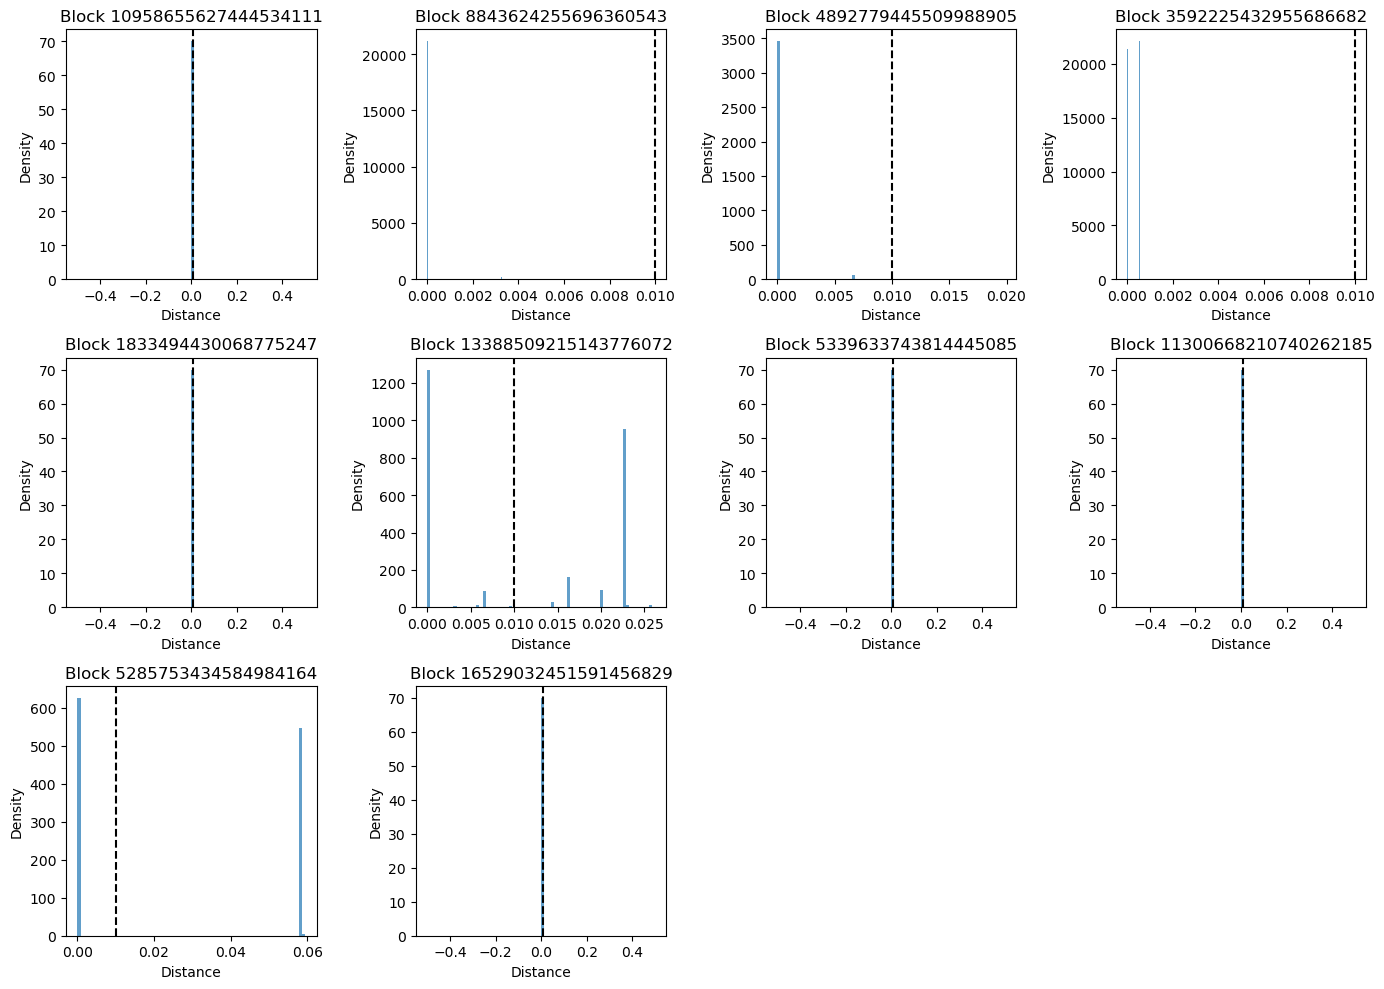

36 / 145 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}]
No ambiguous blocks.
1 / 1 (single isolate)
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}]
No ambiguous blocks.
15 / 17 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}]
No ambiguous blocks.
1 / 1 (single isolate)
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1},

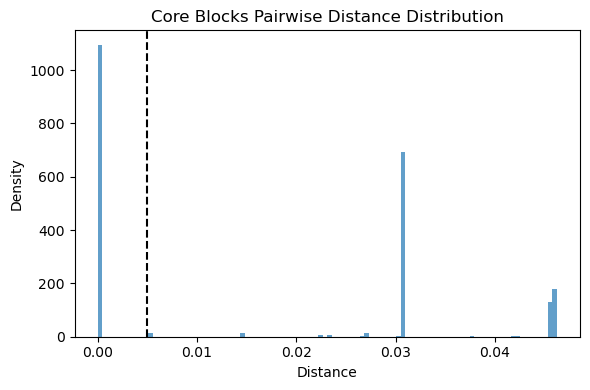

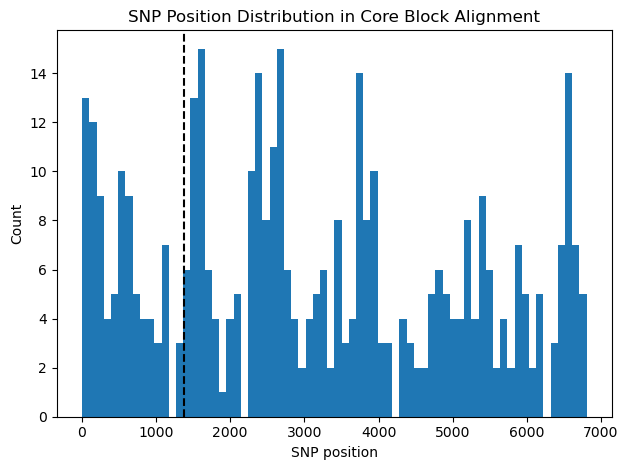

In [3]:
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("RYYAQMEJGY_r__ZTHKZYHPIX_f", plot_consensus=True, plot_pair_dist=True, plot_snp_dist= True, plot_ambiguities= True, clustering_bl_thresh=0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')

In [ ]:
# only one cluster when clustering the whole core genome tree at 0.005 branch length threshold
cluster_map = cluster_tree_by_branch_length("../config/polished_tree.nwk", 0.005)
np.unique(list(cluster_map.values()))

array([0])

In [7]:
strip_newick_suffixes("../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_16671105780806995519_aln.tree", "../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_16671105780806995519_aln_isonames.tree")
strip_newick_suffixes("../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_18146406109094649449_aln.tree", "../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_18146406109094649449_aln_isonames.tree")

Results from manual observation:
- depending on which core block we look at, NZ_AP018784.1 is assigned to different clusters
- clustering based on core block trees seems to reflect by eye estimated consensus clustering pretty well
    - it suggests that the consensus paths obtained with my previous algorithm need to be further merged together
- 0.005 seems to be a good threshold to reconstruct the clusters when looking at the tree

Compare core block trees:
```
cd /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f
treeknit block_16671105780806995519_aln_isonames.tree block_18146406109094649449_aln_isonames.tree --auspice-view
```

### Retrieve insertions and deletions

In [ ]:
example_junction = "RYYAQMEJGY_r__ZTHKZYHPIX_f" # junction has 216 isolates
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")

for i in range(1, 6):
    insertions, deletions = get_insertions_deletions_from_consensus(assignment_df_plotting, consensus_paths_plotting, path_dict, consensus = i)
    write_insertions_fasta(example_junction, example_pangraph, insertions, consensus = i)
    deletions_df = summarize_deletions_consensus(deletions, example_junction, example_pangraph, path_dict, assignment_df_plotting, consensus_id=i, parent_dir = "../results/atb_lookup/deletions", rerun_alignment=True, save_df=True)

# 1 hour




Insertions:
NZ_CP102061.1 INSERTED: [3613498299447014379|-|]_[139818706072034984|-|]
NZ_CP102061.1 INSERTED: [2150995670991051021|+|]
NZ_CP102061.1 INSERTED: [13388509215143776072|+|7385292223686217602_1]_[5339633743814445085|+|7385292223686217602_1]_[11300668210740262185|+|7385292223686217602_1]_[5285753434584984164|+|7385292223686217602_1]
NZ_CP080116.1 INSERTED: [9498745749412710955|+|]
NZ_CP080116.1 INSERTED: [3613498299447014379|-|]_[139818706072034984|-|]
NZ_CP080116.1 INSERTED: [2150995670991051021|+|]
NZ_CP080116.1 INSERTED: [13388509215143776072|+|7385292223686217602_2]
NZ_CP080116.1 INSERTED: [5285753434584984164|+|7385292223686217602_2]
NZ_CP124517.1 INSERTED: [4892779445509988905|-|7385292223686217602_1]_[8843624255696360543|-|7385292223686217602_1]_[5285753434584984164|-|7385292223686217602_2]_[11300668210740262185|-|7385292223686217602_2]_[5339633743814445085|-|7385292223686217602_2]_[13388509215143776072|-|7385292223686217602_2]
NZ_CP124517.1 INSERTED: [13388509215143776

FastTree Version 2.2.0 Double precision
Alignment: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion0_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
Initial topology in 0.02 seconds
Refining topology: 18 rounds ME-NNIs, 2 rounds ME-SPRs, 9 rounds ML-NNIs
      0.11 seconds: ME NNI round 7 of 18, 1 of 19 splits
Total branch-length 0.001 after 0.21 sec

WARNING! This alignment consists of closely-related and very-long sequences.
WARNING! FastTree (or other standard maximum-likelihood tools)
may not be appropriate for aligments of very closely-related sequences
like this one, as FastTree does not account for recombination or gene conversion

      0.23 seconds: ML NNI round 1 of 9, 1 of 19 splits
ML-NNI round 1: LogLk

Wrote tree: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion0_blocks_aln.newick
Processing NZ_CP102061.1 with [5285753434584984164|-|7385292223686217602_1]_[11300668210740262185|-|7385292223686217602_1]_[5339633743814445085|-|7385292223686217602_1]_[13388509215143776072|-|7385292223686217602_1]
Wrote FASTA: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion1_blocks.fa
Wrote alignment: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion1_blocks_aln.fa
Wrote tree: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion1_blocks_aln.newick
Processing NZ_CP102061.1 with [7110182631703495678|+|7385292223686217602_1]
Wrote FASTA: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion2_blocks.fa


FastTree Version 2.2.0 Double precision
Alignment: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion1_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
Initial topology in 0.00 seconds
Refining topology: 13 rounds ME-NNIs, 2 rounds ME-SPRs, 7 rounds ML-NNIs
Total branch-length 0.024 after 0.01 sec
ML-NNI round 1: LogLk = -1231.407 NNIs 2 max delta 3.94 Time 0.01
GTR Frequencies: 0.1974 0.2964 0.2448 0.2615
GTR rates(ac ag at cg ct gt) 0.7165 2.1717 0.8160 0.0455 1.6455 1.0000
Switched to using 20 rate categories (CAT approximation)
Rate categories were divided by 0.629 so that average rate = 1.0
CAT-based log-likelihoods may not be comparable across runs
Use -gamma for approximate but comparable Gamma(20) log-likeliho

Wrote alignment: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion2_blocks_aln.fa
Wrote tree: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion2_blocks_aln.newick
Processing NZ_CP102061.1 with [5339633743814445085|+|7385292223686217602_2]_[11300668210740262185|+|7385292223686217602_2]
Wrote FASTA: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_1/NZ_CP102061.1_deletion3_blocks.fa


...

Wrote alignment: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_5/NZ_CP124506.1_deletion0_blocks_aln.fa


FastTree Version 2.2.0 Double precision
Alignment: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_5/NZ_CP124506.1_deletion0_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
Initial topology in 0.01 seconds
Refining topology: 14 rounds ME-NNIs, 2 rounds ME-SPRs, 7 rounds ML-NNIs
Total branch-length 0.001 after 0.05 sec
ML-NNI round 1: LogLk = -8983.691 NNIs 7 max delta 0.00 Time 0.09
      0.10 seconds: Optimizing GTR model, step 3 of 12
      0.21 seconds: Optimizing GTR model, step 9 of 12
GTR Frequencies: 0.2912 0.1891 0.1650 0.3547
GTR rates(ac ag at cg ct gt) 61.9105 77.5004 71.0644 1.0000 1.0000 1.0000
Switched to using 20 rate categories (CAT approximation)
Rate categories were divided by 0.623 so that average rate = 1.0
CAT-based l

Wrote tree: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_5/NZ_CP124506.1_deletion0_blocks_aln.newick
Reusing alignment/tree for NZ_CP124506.1 deletion1 from NZ_CP124498.1_deletion0
Reusing alignment/tree for NZ_CP124511.1 deletion0 from NZ_CP124498.1_deletion0
Processing NZ_CP124511.1 with [3621101531925085054|+|8046715219054472333_1]_[10783653725007775588|+|8046715219054472333_1]_[15640176264655488742|+|8046715219054472333_1]_[16682535971851667967|+|8046715219054472333_1]_[17789862543328019283|+|8046715219054472333_1]_[2089333824671448751|+|8046715219054472333_1]_[9661425280189610721|+|8046715219054472333_1]_[10490460740929557719|+|8046715219054472333_1]_[13125551893097988568|+|8046715219054472333_1]_[12885162208417639662|+|8046715219054472333_1]_[10401150471569339000|+|8046715219054472333_1]_[8577334121550535376|+|8046715219054472333_1]_[15911069344949453994|+|8046715219054472333_1]_[9350095107367691978|+|8046715219054472333_1]_[510116479221794419|+|8046715219

FastTree Version 2.2.0 Double precision
Alignment: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_5/NZ_CP124511.1_deletion1_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
Initial topology in 0.03 seconds
Refining topology: 15 rounds ME-NNIs, 2 rounds ME-SPRs, 7 rounds ML-NNIs
      0.19 seconds: ME NNI round 6 of 15, 1 of 11 splits
      0.33 seconds: ME NNI round 11 of 15, 1 of 11 splits
Total branch-length 0.001 after 0.35 sec

WARNING! This alignment consists of closely-related and very-long sequences.
WARNING! FastTree (or other standard maximum-likelihood tools)
may not be appropriate for aligments of very closely-related sequences
like this one, as FastTree does not account for recombination or gene conversion

ML-NNI round 1: Log

Wrote tree: ../results/atb_lookup/deletions/RYYAQMEJGY_r__ZTHKZYHPIX_f/consensus_5/NZ_CP124511.1_deletion1_blocks_aln.newick
Reusing alignment/tree for NZ_CP124339.1 deletion0 from NZ_CP124498.1_deletion0
Reusing alignment/tree for NZ_CP124502.1 deletion0 from NZ_CP124498.1_deletion0
Reusing alignment/tree for NZ_CP124345.1 deletion0 from NZ_CP124498.1_deletion0
Reusing alignment/tree for NZ_CP124475.1 deletion0 from NZ_CP124498.1_deletion0
Reusing alignment/tree for NZ_CP124495.1 deletion0 from NZ_CP124498.1_deletion0


In [9]:
# TODO: want quick method to quantify deletions without alignment

In [10]:
load_all_deletions_summaries("../results/atb_lookup/deletions", example_junction, save_df=True).sort_values(['consensus','path']).iloc[30:80]

,junction_name,consensus,genome_name,path,deletion,consensus_sequence,length
38,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_AP022362.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
54,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP124442.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
58,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_LS999560.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
59,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP124405.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
60,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP051609.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
66,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_OX030701.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
69,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_JAPVBX010000001.1,[13388509215143776072|+|7385292223686217602_2]...,deletion2,----------------------------------------------...,13401
82,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_OY019088.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
85,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP115324.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401
90,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP124410.1,[13388509215143776072|+|7385292223686217602_2]...,deletion0,----------------------------------------------...,13401


In [11]:
insertions

{'NZ_CP124471.1': [[8987038859492738001|-|15214930222195849744_1]],
 'NZ_CP116085.1': [[8987038859492738001|-|4975549513306979906_1],
  [10427553165367559225|+|]],
 'NZ_CP124506.1': [[8987038859492738001|+|7120694477255526700_1]],
 'NZ_CP124334.1': [[16424442392483324144|+|8046715219054472333_1]_[17141892380880723886|+|8046715219054472333_1]_[3226134370544314880|+|8046715219054472333_1]_[13612719202651021848|+|8046715219054472333_1]],
 'NZ_CP128916.1': [[8987038859492738001|-|13441773807216920667_1]],
 'NZ_CP124511.1': [[8987038859492738001|+|7385292223686217602_1],
  [16424442392483324144|+|8046715219054472333_1]_[17141892380880723886|+|8046715219054472333_1]_[3226134370544314880|+|8046715219054472333_1]_[13612719202651021848|+|8046715219054472333_1]],
 'NZ_CP103465.1': [[8987038859492738001|-|9064600273910720801_1]],
 'NZ_CP015076.1': [[8987038859492738001|+|6190733325649628175_1]]}

### See whether block tree clustering is consistent with consensus block tree clustering
1. decide on sensible thresholds for core block tree clustering
2. Cluster by trees based on single blocks and see if clustering follows consensus paths

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_70434/558142800.py:5: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,file,block_id,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len,tree_built
65,block_6362012061147730151_aln.fa,6362012061147730151,196,1085,1075,10,0,0,0.000000,0.000000,0.000000,196,196,False,False,1083,True
133,block_12427157752372396874_aln.fa,12427157752372396874,3,1509,1509,0,0,0,0.000000,0.000000,0.000000,3,3,False,False,1509,True
173,block_17897566196295069196_aln.fa,17897566196295069196,182,1320,1320,0,0,0,0.000000,0.000000,0.000000,182,182,False,False,1320,True
77,block_7166485448600219032_aln.fa,7166485448600219032,145,1786,1779,7,0,1,0.000562,0.000008,0.000004,145,145,False,False,1779,True
61,block_6010508614880330566_aln.fa,6010508614880330566,195,1433,1426,7,0,2,0.001403,0.000014,0.000007,195,195,False,False,1429,True
114,block_10480880799551222441_aln.fa,10480880799551222441,145,1864,1864,0,0,2,0.001073,0.000015,0.000007,145,145,False,False,1864,True
57,block_5598563553016563611_aln.fa,5598563553016563611,140,1623,1623,0,0,20,0.012323,0.000018,0.000009,140,139,True,False,1623,True
141,block_13401516282804455284_aln.fa,13401516282804455284,182,1158,1143,8,7,2,0.001750,0.000019,0.000010,182,182,False,False,1143,True
137,block_12922793938882367282_aln.fa,12922793938882367282,195,1064,1061,0,3,10,0.009425,0.000019,0.000010,195,195,False,False,1060,True
11,block_1448964389002043948_aln.fa,1448964389002043948,145,5385,5385,0,0,22,0.004085,0.000020,0.000010,145,145,False,False,5385,True


/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_70434/558142800.py:8: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



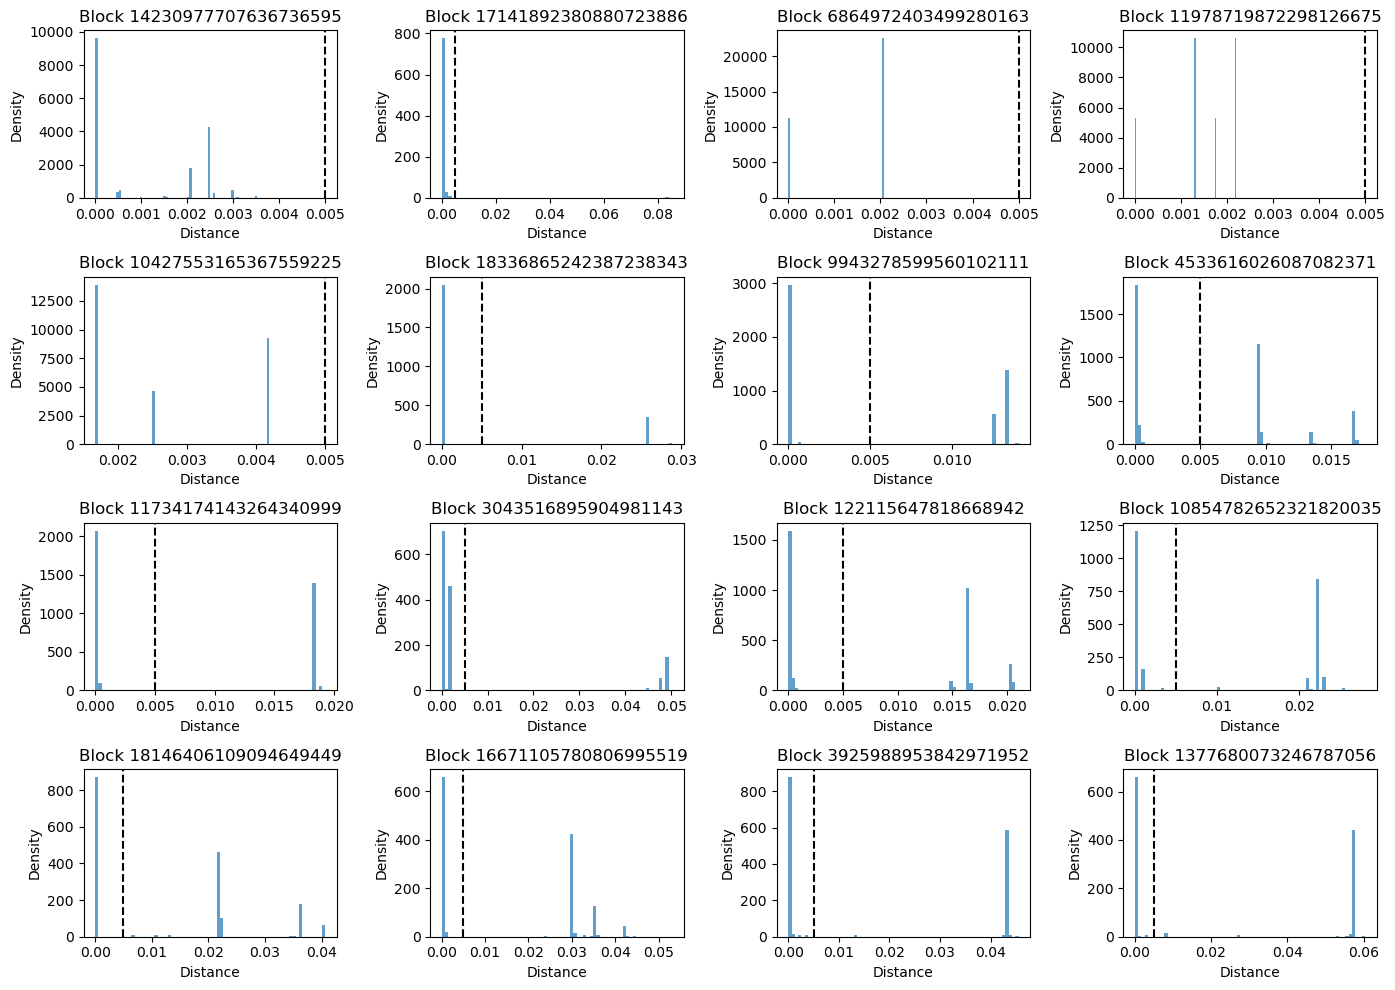

In [12]:
example_junction = "RYYAQMEJGY_r__ZTHKZYHPIX_f" # junction has 216 isolates
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")

summary_df = pd.read_csv(f"../results/block_alignments/{example_junction}/{example_junction}_alignment_stats.csv")
display(summary_df.sort_values('avg_pairwise_dist')[summary_df.tree_built == True])

_, pair_dists = summarize_block_msas(example_junction, save_df=False, return_pairwise_dists=True)
block_ids = summary_df.sort_values('avg_pairwise_dist')[(summary_df.tree_built == True) & (summary_df.avg_pairwise_dist > 0.001)].block_id

plot_block_distance_distribution(
    pair_dists,
    block_ids,
    bins=70,
    cols=4,
    figsize=(14, 10),
    vline=0.005,                     # draw a vertical line at distance 0.05
    vline_kwargs={"color": "black", "linestyle": "--"}
)


In [13]:
block_id = 1377680073246787056 # block with highest diversity that is long enough and has enough sequences
#block_id = 3925988953842971952 # block with second highest diversity that is long enough and has enough sequences
#block_id = 8046715219054472333 # highest diversity block shared only by consensus_6, consensus_7 blocks
#block_id = 16671105780806995519	# first core block, also block with highest diversity that is present in all isolates --> gives very good clustering that fits desired consensus paths
#block_id = 18146406109094649449 # second core block


In [14]:
def visualize_block_clustering(pangraph, junction_name, consensus_paths, assignment_df, block_id, dist_threshold=0.005):

    tree_path = Path(f"../results/block_alignments/{junction_name}/block_{block_id}_aln.tree")

    cluster_map = cluster_tree_by_branch_length(tree_path, dist_threshold)
    cluster_map = simplify_cluster_keys(cluster_map)

    fig = plot_junction_pangraph_interactive(
        pangraph,
        show_consensus=True,
        consensus_paths=consensus_paths,
        assignments=assignment_df,
        order="tree",
        cluster_map=cluster_map,
        title = f"Junction Block Structure with block {block_id} Tree Clustering"
    )
    display(fig)

    return cluster_map

In [15]:
# block with highest diversity that is long enough and has enough sequences (blue block in the second half)
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 1377680073246787056, dist_threshold=0.005)
# clustering is consistent with consensus path clustering, two sequences are retrieved as a subcluster of consensus_1

# second highest diversity, light blue block in the first half
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 3925988953842971952, dist_threshold=0.005)
# clustering matches consensus path clustering for the consensus paths where block is present

# only present in consensus_5, red block in the middle
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 8046715219054472333, dist_threshold=0.005)
# all sequences cluster together as expected

In [16]:
for bid in block_ids:
    cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = bid, dist_threshold=0.005)

Results:
- most blocks fit the clustering of the core blocks
- some blocks suggest sub-clustering of some of the consensus baths (usually individual (1 or 2) isolates that differ), still consistent with core block clustering
- for some blocks suggest that several consensus paths should be the same cluster, e.g. 3043516895904981143 (also around 1000bp)
- 10854782652321820035 shows a little bit of intermixing between clusters, relativly short (around 1000bp, light blue)

### Check out other junctions

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/JVNRLCFAVD_f__PLTCZQCVRD_r
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0},

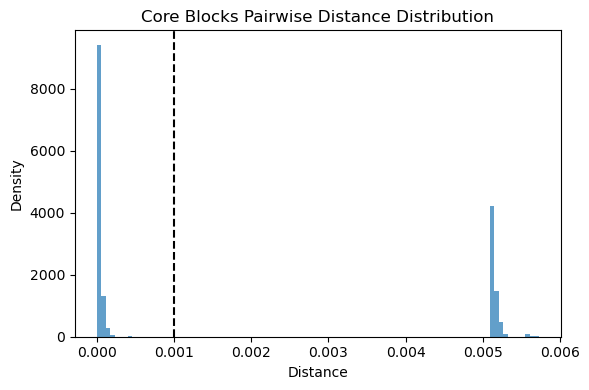

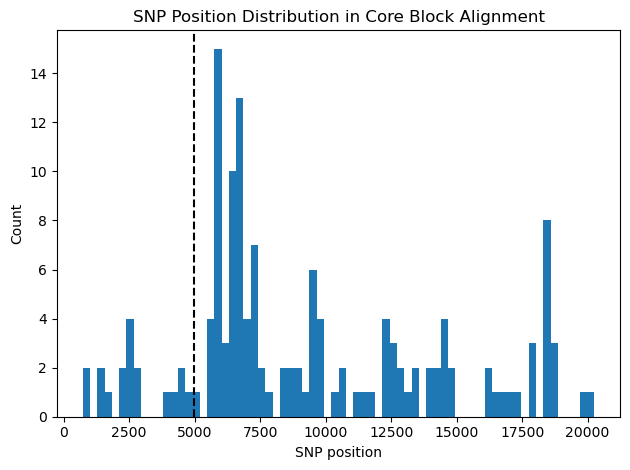

In [11]:
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("JVNRLCFAVD_f__PLTCZQCVRD_r", clustering_bl_thresh= 0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/ATPWUNKKID_f__KKPYPKGMXA_f
[{1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}]
No ambiguous blocks.
169 / 169 isolates share the majority path
[{1}, {1}]
No ambiguous blocks.
52 / 52 isolates share the majority path


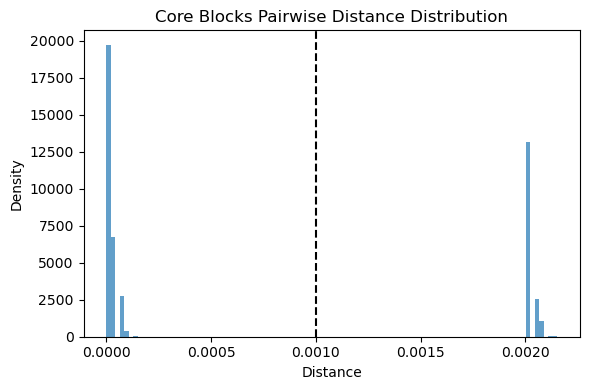

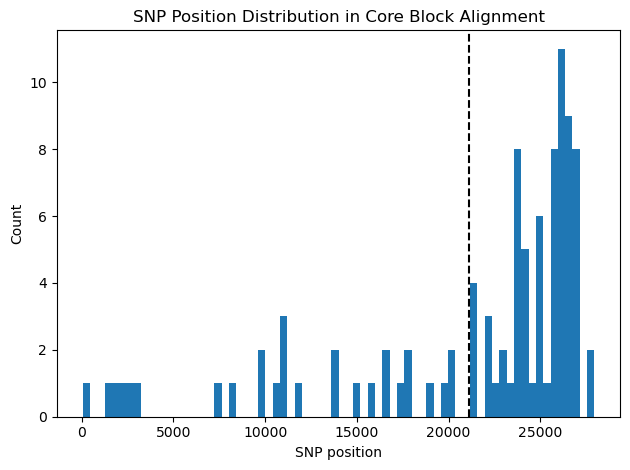

In [10]:
# branch length threshold 0.001 gives two consensus paths (its not directly representative of phage insertion and not insertion, paths that are in consensus 1 all have an insertion but not all of the ones in consensus 2 have one), 0.005 only one, 
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("ATPWUNKKID_f__KKPYPKGMXA_f", clustering_bl_thresh= 0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/EJPOGALASQ_f__KUIFCLFQSI_r
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0},

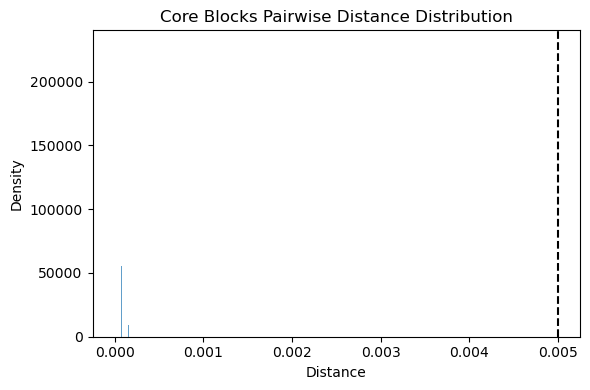

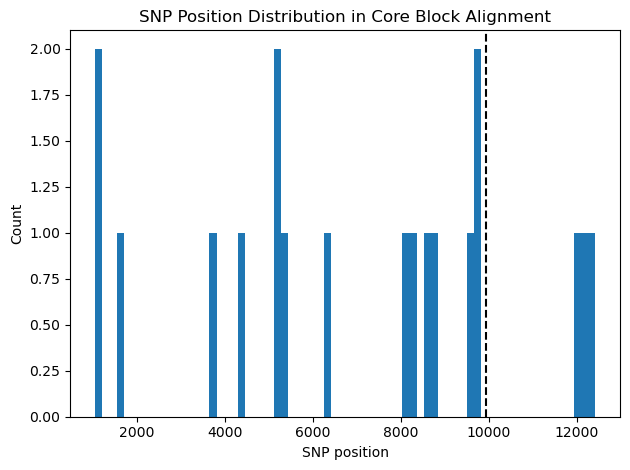

In [9]:
# should all be one cluster
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("EJPOGALASQ_f__KUIFCLFQSI_r", clustering_bl_thresh= 0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}]
No ambiguous blocks.
160 / 170 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}]
No ambiguous blocks.
52 / 52 isolates share the majority path


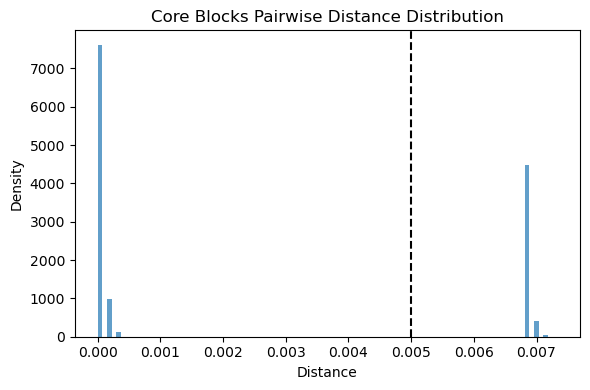

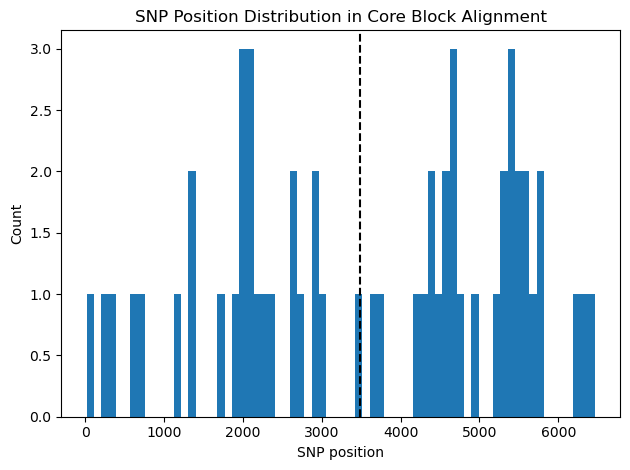

In [8]:
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("CIRMBUYJFK_f__CWCCKOQCWZ_r", clustering_bl_thresh= 0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Compare the clusterings between different blocks. To do that look at all pairs of two isolates and compare whether they are in the same cluster or in different clusters. Then calculate a score how many of the isolates that are in the same cluster are also in the same cluster on a different block and how many aren't. Also calculate a score how many of the isolates that are in different clusters are also in different clusters on a different block. For now just use isolate names and ignore duplicate blocks.